# CheXpert vs SIIM-ACR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom

In [2]:
def hist(img, title):
    # Sample data
    data = img.flatten()

    # Create a ggplot-style histogram
    plt.figure(figsize=(8, 6))
    plt.hist(data, bins=20, color='skyblue', edgecolor='gray', alpha=0.7)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(title)

    # Add gridlines and change axis color
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='black', linewidth=0.5)

    # Customize the appearance of the plot
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.edgecolor'] = 'gray'
    plt.rcParams['axes.linewidth'] = 0.8

    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.show()

In [3]:
def hist_cdf(img, title, savefig=None):
    # Sample data
    data = img.flatten()

    # Create a figure
    fig, ax1 = plt.subplots(figsize=(6, 6))

    # Create the histogram
    n, bins, patches = ax1.hist(data, bins=20, color='skyblue', edgecolor='gray', alpha=0.7, label='Pixel Intensity Histogram', density=True)
    # ax1.set_xlabel('Value')
    # ax1.set_ylabel('Frequency', color='skyblue')
    # ax1.tick_params(axis='y', labelcolor='skyblue')
    if title:
        ax1.set_title(f'{title}')
    ax1.set_xticks([])
    ax1.set_yticks([])

    # Create a second y-axis (right) for the CDF
    ax2 = ax1.twinx()

    # Calculate the CDF
    cdf = np.cumsum(n) * np.diff(bins)
    ax2.plot(bins[:-1], cdf, color='salmon', linewidth=2, label='Cumulative Distribution\nFunction')
    # ax2.set_ylabel('Cumulative Probability', color='salmon')
    # ax2.tick_params(axis='y', labelcolor='salmon')
    ax2.set_xticks([])
    ax2.set_yticks([])

    # Add gridlines and change axis color for both axes
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.axhline(0, color='black', linewidth=0.5)

    # Customize the appearance of the plot
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 20
    plt.rcParams['axes.edgecolor'] = 'gray'
    plt.rcParams['axes.linewidth'] = 0.8

    # Remove top and right spines for both axes
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Add legends for both axes
    ax1.legend(loc='upper left', bbox_to_anchor=(0.0, 0.9))
    ax2.legend(loc='upper left', bbox_to_anchor=(0.0, 0.8))
    
    if not savefig is None:
        plt.tight_layout()
        plt.savefig(f"{savefig}.png")

    plt.show()

# CheXpert

In [4]:
cxp = pd.read_csv("/opt/NAS3/CXR/CheXpert-v1.0/train.csv")

In [5]:
cxp.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0/train/patient00001/study1/view1_...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0/train/patient00002/study1/view2_...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0/train/patient00003/study1/view1_...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


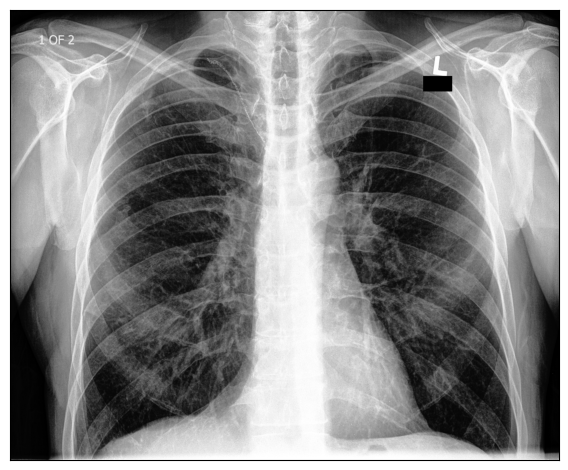

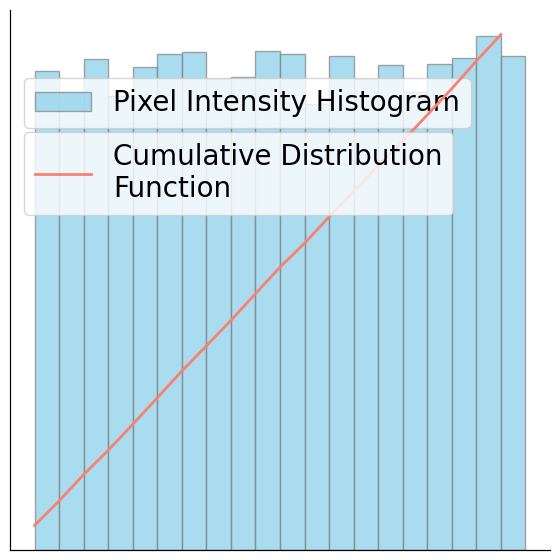

In [6]:
img_cxp = f"/opt/NAS3/CXR/CheXpert-v1.0/train/patient22404/study1/view1_frontal.jpg"

plt.figure(dpi=100)
img = plt.imread(img_cxp).copy()
img[340:420, -700:-550] = 0
plt.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False) 
plt.tight_layout()
plt.imshow(img, 'gray')
# plt.savefig("cxr_chexpert.png")
plt.show()

hist_cdf(img, None, "hist_CheXpert")

# SIIM-ACR
dcm.SOPInstanceUID = '1.2.276.0.7230010.3.1.4.8323329.2387.1517875172.498321'

Path = '/dicom-images-train/1.2.276.0.7230010.3.1.2.8323329.2387.1517875172.498320/1.2.276.0.7230010.3.1.3.8323329.2387.1517875172.498319/1.2.276.0.7230010.3.1.4.8323329.2387.1517875172.498321.dcm'

In [7]:
siim = pd.read_csv("/home/tdapame/Data/Frank/SIIM_ACR_Pneumothorax/SIIM_ACR_input_test.csv")

In [8]:
siim.head()

,Unnamed: 0,PID,ImageId,Pneumothorax,Path,No Finding
0,4,4,1.2.276.0.7230010.3.1.4.8323329.32579.15178751...,1,/dicom-images-train/1.2.276.0.7230010.3.1.2.83...,0
1,5,5,1.2.276.0.7230010.3.1.4.8323329.32579.15178751...,1,/dicom-images-train/1.2.276.0.7230010.3.1.2.83...,0
2,8,8,1.2.276.0.7230010.3.1.4.8323329.11364.15178752...,0,/dicom-images-train/1.2.276.0.7230010.3.1.2.83...,1
3,10,10,1.2.276.0.7230010.3.1.4.8323329.4440.151787518...,1,/dicom-images-train/1.2.276.0.7230010.3.1.2.83...,0
4,13,13,1.2.276.0.7230010.3.1.4.8323329.12743.15178752...,1,/dicom-images-train/1.2.276.0.7230010.3.1.2.83...,0


In [9]:
sampled_siim_acr_path = "/dicom-images-train/1.2.276.0.7230010.3.1.2.8323329.2387.1517875172.498320/1.2.276.0.7230010.3.1.3.8323329.2387.1517875172.498319/1.2.276.0.7230010.3.1.4.8323329.2387.1517875172.498321.dcm"

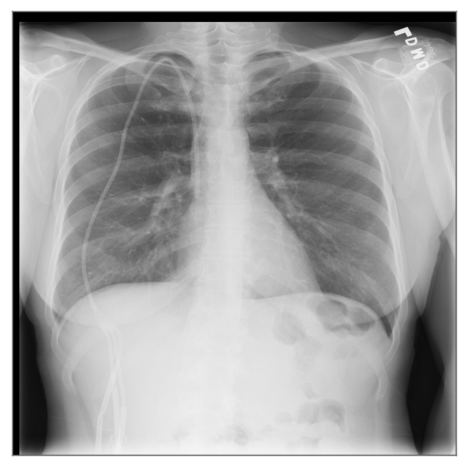

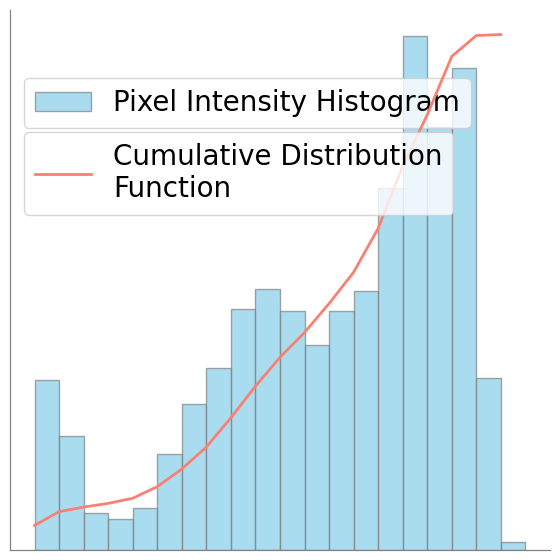

In [10]:
dcm = pydicom.dcmread(f"/home/tdapame/Data/Frank/SIIM_ACR_Pneumothorax{sampled_siim_acr_path}")
plt.figure(dpi=120)
plt.imshow(dcm.pixel_array, 'gray')
plt.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False) 
plt.show()

hist_cdf(dcm.pixel_array, None, "hist_SIIM-ACR")